plot_PCA notebook
- Generates PCA visualizations of compositional search space in two dimensions, allowing analysis of compositional variation in FALCON generated LNPs 
- Ensure the <u>R kernel (falcon-env)</u> is selected.
- Run configuration and PCA computation before proceeding to plotting
- Note: This script requires composition datasets of LNP formulations

In [58]:
### Required Run Parameters ### 

#Name of the csv file, used to extract composition data
DATASET_NAME = 'Demo_Norm_RAMOS_THP1_Single_Dual_Objective_4ITER_MC3_DSPC'  

RUN_NAME = "Demo_Results" #for saving generated plots
cell_type = 'Selectivity' # only needed if you want to shade by performance
#cell_type = 'Selectivity'

### Configuration ###

In [59]:
library(ggplot2)

In [60]:
# Updated custom theme
custom_theme <- theme(
  plot.background = element_rect(fill = "transparent", colour = NA),  # Plot background
  panel.background = element_rect(fill = "transparent", colour = NA),  # Main panel
  plot.title = element_text(size = 35, hjust = 0.5, face = "plain", colour = "black"), 
  axis.text.y = element_text(size = 30, face = "plain", colour = "black"),  
  axis.text.x = element_text(size = 30, face = "plain", colour = "black"), 
  axis.title.x = element_text(size = 35, face = "plain", colour = "black"),  
  axis.title.y = element_text(size = 35, face = "plain", colour = "black"), 
  axis.line.x.bottom = element_line(color = "black", size = 1),  # Thicker black x-axis line
  axis.line.y.left = element_line(color = "black", size = 1),    # Thicker black y-axis line
  axis.ticks.length = unit(0.4, "cm"),  # Bigger tick marks
  axis.ticks = element_line(color = "black", size = 1.5),  # Thicker black tick marks
  legend.background = element_blank(),
  legend.key = element_blank(),
  panel.grid.major = element_blank(),
  panel.grid.minor = element_blank(),
  legend.text = element_text(size = 22),  
  legend.title = element_text(size = 22),  
  legend.key.size = unit(3, "lines")
)

In [61]:
# Build full path: ../output/RUN_NAME/PCA
output_path <- file.path("..", "output", RUN_NAME, "PCA")

# Create directory (including parents if needed)
if (!dir.exists(output_path)) {
  dir.create(output_path, recursive = TRUE)
}

### PCA Computation ###

In [62]:
# import data 
data <- read.csv(paste0("../datasets/", DATASET_NAME, ".csv"))
head(data)

ï..Formula_label,FALCON_ID,Iter,Opt_Method,Max_Cell_Target,Ionizable_lipid,Helper_lipid,NP_ratio,IL.HL,HL_IL.HL,PEG_PEG.Chol,MC3_PcntMolar,DSPC_PcntMolar,Cholesterol_PcntMolar,DMGPEG_PcntMolar,nLnLE_RAMOS,nLnLE_THP1,nLnLE_Selectivity
1,F0001,0,N/A,N/A,Dlin-MC3-DMA,DSPC,4,20,50,9.090909,10,10,72.72727,7.272727,1.460645,0.4881053,0.9725393
2,F0002,0,N/A,N/A,Dlin-MC3-DMA,DSPC,8,20,50,9.090909,10,10,72.72727,7.272727,-1.288202,0.5427043,-1.8309060
3,F0003,0,N/A,N/A,Dlin-MC3-DMA,DSPC,12,20,50,9.090909,10,10,72.72727,7.272727,-1.409167,0.9291403,-2.3383077
4,F0004,0,N/A,N/A,Dlin-MC3-DMA,DSPC,4,50,50,9.090909,25,25,45.45455,4.545455,2.978449,0.9454763,2.0329732
5,F0005,0,N/A,N/A,Dlin-MC3-DMA,DSPC,8,50,50,9.090909,25,25,45.45455,4.545455,2.748254,1.3162603,1.4319938
6,F0006,0,N/A,N/A,Dlin-MC3-DMA,DSPC,12,50,50,9.090909,25,25,45.45455,4.545455,2.556686,1.6625323,0.8941541


In [63]:
# Run PCA on the dataset, keeping only the first two principal components
selected_cols <- c("NP_ratio", "HL_IL.HL", "IL.HL", "PEG_PEG.Chol")

pca <- prcomp(data[, selected_cols], center = TRUE, scale. = TRUE)
summary(pca) # Summarizes importance of the principal components

# Extract the principal components
pca_data <- data.frame(pca$x)

# Combine with the species data for plotting
pca_data$Iter <- data$Iter
pca_data$Opt_Method <- data$Opt_Method
RLU_col <- paste0("nLnLE_", cell_type)
pca_data$RLU <- data[[RLU_col]]
pca_data$Cell_Target <- data$Max_Cell_Target
pca_data$Formula_label <- data$ï..Formula_label

print(head(pca_data))

Importance of components:
                          PC1    PC2    PC3    PC4
Standard deviation     1.3551 0.9640 0.8303 0.7382
Proportion of Variance 0.4591 0.2323 0.1723 0.1363
Cumulative Proportion  0.4591 0.6914 0.8638 1.0000

        PC1         PC2         PC3         PC4 Iter Opt_Method        RLU
1 -2.497386 -1.48721478 -0.01048281 -0.17715092    0        N/A  0.9725393
2 -2.201571 -1.54328503  0.14528256 -0.55635967    0        N/A -1.8309060
3 -1.905756 -1.59935527  0.30104792 -0.93556842    0        N/A -2.3383077
4 -1.970442  0.12702462  0.21616905  0.08832685    0        N/A  2.0329732
5 -1.674627  0.07095438  0.37193442 -0.29088190    0        N/A  1.4319938
6 -1.378812  0.01488414  0.52769979 -0.67009065    0        N/A  0.8941541
  Cell_Target Formula_label
1         N/A             1
2         N/A             2
3         N/A             3
4         N/A             4
5         N/A             5
6         N/A             6


### Plotting ###

Saving 6.67 x 6.67 in image


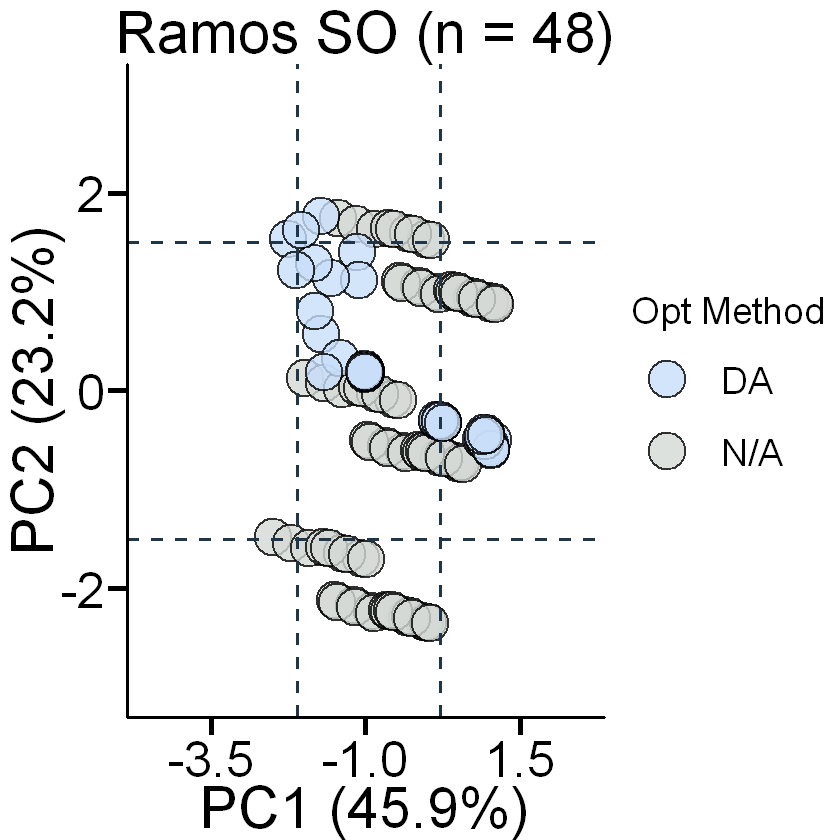

In [64]:
#Visualize SO RAMOS Formulations

hist_data <- pca_data[
  pca_data$Iter == 0 |
  (pca_data$Opt_Method == "DA" & pca_data$Cell_Target == "RAMOS"),
  ]

custom_colors <- c("N/A" = "#d4d9d6", "DA" = "#C8DEF9")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, size = 10, color = "black", stroke = 1, alpha = 0.8) +  # Black outline added
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1.5, 1.5), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-2.1, 0.2), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom color scale for the fill
  scale_fill_manual(values = custom_colors) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-3.5, -1, 1.5), limits = c(-4.5, 2.5)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  custom_theme +
  labs(title = "Ramos SO (n = 48)",
       x = "PC1 (45.9%)",
       y = "PC2 (23.2%)",
       fill = "Opt Method")

filename <- paste0("../output/", RUN_NAME, "/PCA/RAMOS_SO_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)

Saving 6.67 x 6.67 in image


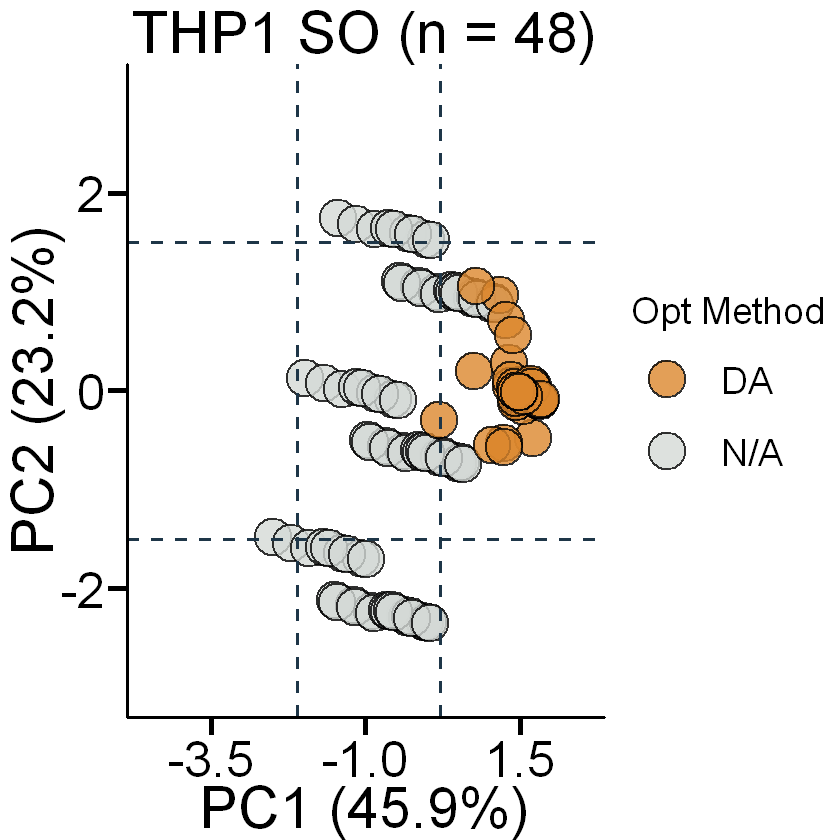

In [65]:
#Visualize SO THP1 Formulations

hist_data <- pca_data[
  pca_data$Iter == 0 |
  (pca_data$Opt_Method == "DA" & pca_data$Cell_Target == "THP1"),
  ]

custom_colors <- c("N/A" = "#d4d9d6", "DA" = "#dc872d")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, size = 10, color = "black", stroke = 1, alpha = 0.8) +  # Black outline added
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1.5, 1.5), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-2.1, 0.2), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom color scale for the fill
  scale_fill_manual(values = custom_colors) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-3.5, -1, 1.5), limits = c(-4.5, 2.5)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  custom_theme +
  labs(title = "THP1 SO (n = 48)",
       x = "PC1 (45.9%)",
       y = "PC2 (23.2%)",
       fill = "Opt Method")

filename <- paste0("../output/", RUN_NAME, "/PCA/THP1_SO_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)

Saving 6.67 x 6.67 in image
Warning message:
"Removed 1 rows containing missing values (geom_point)."Warning message:
"Removed 1 rows containing missing values (geom_point)."

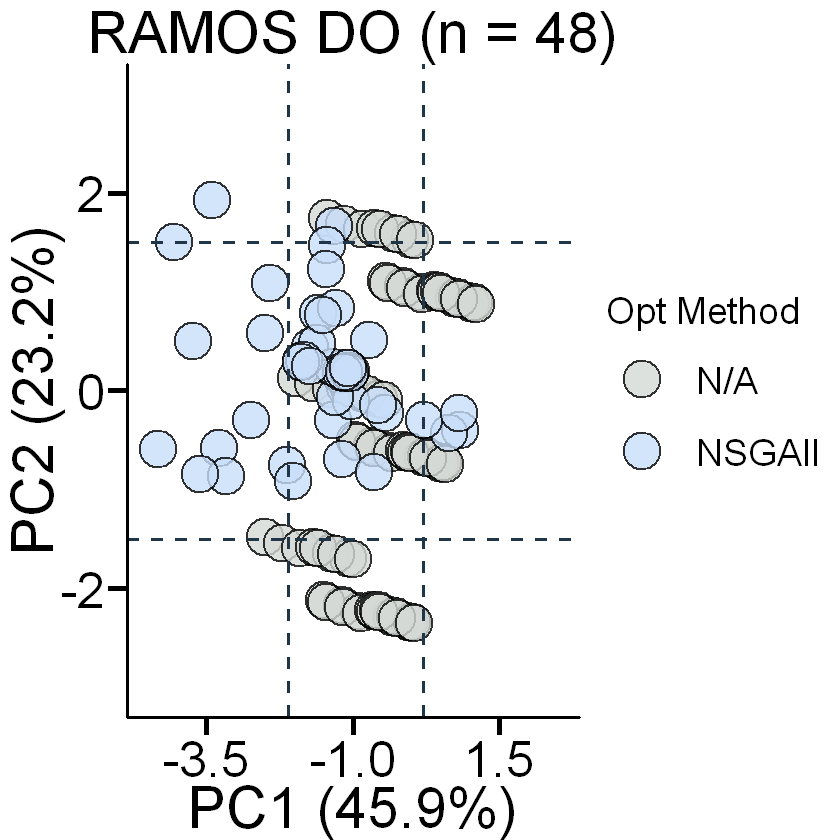

In [66]:
#Visualize DO RAMOS Formulations

hist_data <- pca_data[
  pca_data$Iter == 0 |
  (pca_data$Opt_Method == "NSGAII" & pca_data$Cell_Target == "RAMOS"),
  ]

custom_colors <- c("N/A" = "#d4d9d6", "NSGAII" = "#C8DEF9")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, size = 10, color = "black", stroke = 1, alpha = 0.8) +  # Black outline added
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1.5, 1.5), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-2.1, 0.2), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom color scale for the fill
  scale_fill_manual(values = custom_colors) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-3.5, -1, 1.5), limits = c(-4.5, 2.5)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  custom_theme +
  labs(title = "RAMOS DO (n = 48)",
       x = "PC1 (45.9%)",
       y = "PC2 (23.2%)",
       fill = "Opt Method")

filename <- paste0("../output/", RUN_NAME, "/PCA/RAMOS_DO_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)

Saving 6.67 x 6.67 in image


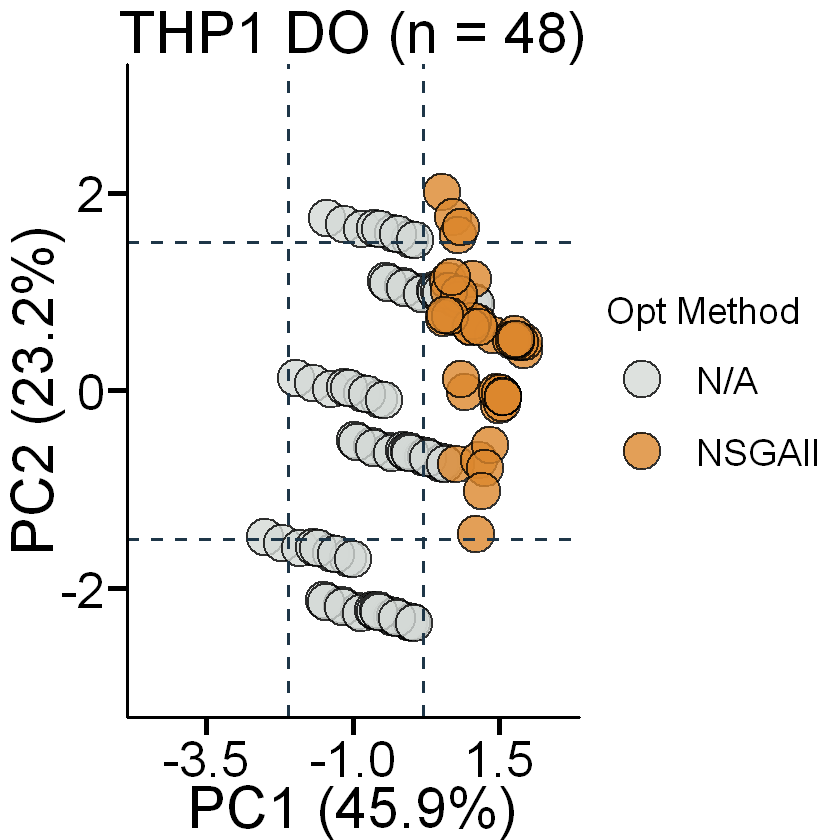

In [67]:
#Visualize DO THP1 Formulations

hist_data <- pca_data[
  pca_data$Iter == 0 |
  (pca_data$Opt_Method == "NSGAII" & pca_data$Cell_Target == "THP1"),
  ]

custom_colors <- c("N/A" = "#d4d9d6", "NSGAII" = "#dc872d")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, size = 10, color = "black", stroke = 1, alpha = 0.8) +  # Black outline added
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1.5, 1.5), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-2.1, 0.2), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom color scale for the fill
  scale_fill_manual(values = custom_colors) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-3.5, -1, 1.5), limits = c(-4.5, 2.5)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  custom_theme +
  labs(title = "THP1 DO (n = 48)",
       x = "PC1 (45.9%)",
       y = "PC2 (23.2%)",
       fill = "Opt Method")

filename <- paste0("../output/", RUN_NAME, "/PCA/THP1_DO_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)